In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os

In [3]:
PREPATH = '../Data/PreProcessed/'
POSPATH = '../Data/PosProcessed/'
CLASSPATH = '../Data/Classification/'

---

#### **01 ) - Instânciando Dados**

---

---

##### A ) Instânciando PosDatasetsClean

In [4]:
df_PosDatasetsClean = pd.read_csv(os.path.join(POSPATH, 'PosDatasetsClean.csv'))
df_PosDatasetsClean.head()

,id,Dataset_Title,URL,is_encrypted,Columns,Columns_Count,Numeric_Cols,Categorical_Cols,Memory_Usage_MB
0,CRED-002,South German Credit,https://www.kaggle.com/datasets/sid321axn/sout...,0,"['status', 'duration', 'credit_history', 'purp...",21,3,18,"0,26"
1,CRED-004,Australian Credit Approval,https://www.kaggle.com/datasets/bfueojjsjdjsl/...,1,"['CustomerID', 'A1', 'A2', 'A3', 'A4', 'A5', '...",16,16,0,"0,03"
2,CRED-005,Japanese Credit Screening,https://www.kaggle.com/datasets/xiangshan1989/...,1,"['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8...",16,7,9,"0,03"
3,CRED-007,Polish Companies Bankruptcy,https://www.kaggle.com/datasets/stealthtechnol...,1,"['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8...",66,66,0,"20,47"
4,CRED-008,Qualitative Bankruptcy,https://www.kaggle.com/datasets/jagadeesh23/qu...,1,"['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'Class']",7,0,7,"0,01"


---

##### B ) Instânciando MacroTaxonomyClassification

In [5]:
df_MacroTC = pd.read_csv(os.path.join(CLASSPATH, 'MacroTaxonomyClassification.csv'))
df_MacroTC = df_MacroTC[['id', 'Col', 'Col_Standardized']]
df_MacroTC.head()

,id,Col,Col_Standardized
0,CRED-002,status,INSTITUTIONAL and FINANCIAL
1,CRED-002,duration,INSTITUTIONAL and FINANCIAL
2,CRED-002,credit_history,INSTITUTIONAL and FINANCIAL
3,CRED-002,purpose,INSTITUTIONAL and FINANCIAL
4,CRED-002,amount,INSTITUTIONAL and FINANCIAL


---

##### C ) Instânciando MicroTaxonomyClassification

In [6]:
df_MicroTC = pd.read_csv(os.path.join(CLASSPATH, 'MicroTaxonomyClassificationAdt.csv'))
df_MicroTC = df_MicroTC[['variavel_original', 'conceito_padronizado', 'macro_categoria']]
df_MicroTC.head()

,variavel_original,conceito_padronizado,macro_categoria
0,status,loan_status,INSTITUTIONAL and FINANCIAL
1,duration,payment_term_duration,INSTITUTIONAL and FINANCIAL
2,credit_history,credit_rating,INSTITUTIONAL and FINANCIAL
3,purpose,loan_purpose,INSTITUTIONAL and FINANCIAL
4,amount,loan_amount,INSTITUTIONAL and FINANCIAL


---

#### **02 ) - Gráficos Simples**

---

---

##### A ) Proporção de Datasets Criptografados

- <p align="justify">O gráfico mostra como as bases de crédito se dividem em relação à privacidade. A fatia de dados abertos (is_encrypted == 0) mantém o nome original das variáveis, o que facilita muito o nosso trabalho com processamento de linguagem natural. Já o grupo de dados anonimizados (is_encrypted == 1) passou por um mascaramento para proteger informações sensíveis.'</p>

In [7]:
df_encrypted = df_PosDatasetsClean['is_encrypted'].value_counts(normalize=True).reset_index().copy()
df_encrypted

,is_encrypted,proportion
0,0,0.745098
1,1,0.254902


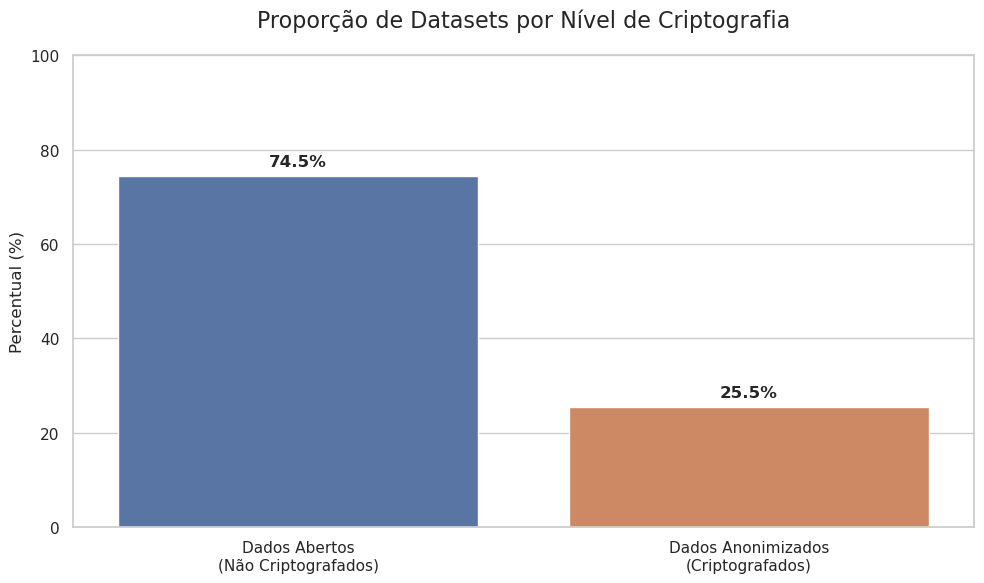

In [8]:
df_plot = df_encrypted.copy()
df_plot.columns = ['is_encrypted', 'proportion']
df_plot['Percentage'] = df_plot['proportion'] * 100
mapeamento = {0: 'Dados Abertos\n(Não Criptografados)', 1: 'Dados Anonimizados\n(Criptografados)'}
df_plot['Status'] = df_plot['is_encrypted'].map(mapeamento)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Status', y='Percentage', hue='Status',data=df_plot, palette=['#4C72B0', '#DD8452'], legend=False,ax=ax)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height + 1.5),ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Proporção de Datasets por Nível de Criptografia', fontsize=16, pad=20)
ax.set_ylabel('Percentual (%)', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(0, 100) 
plt.tight_layout()
plt.show()

---

##### B ) Percentual das Macrocategorias para as Variáveis

- <p align="justify">Os gráficos apresentam a distribuição percentual das categorias macro identificadas no processo de classificação. O primeiro gráfico (G1) detalha a composição completa da base, incluindo o volume de dados ainda não categorizados. Já o segundo gráfico (G2) oferece uma visão refinada, removendo a classe "UNCLASSIFIED" para evidenciar a proporção relativa entre as categorias de crédito efetivamente rotuladas, permitindo uma análise mais clara da relevância de cada segmento no modelo.</p>

In [9]:
df_MacroTC_value_counts = df_MacroTC['Col_Standardized'].value_counts(normalize=True).reset_index().copy()
df_MacroTC_value_counts

,Col_Standardized,proportion
0,INSTITUTIONAL and FINANCIAL,0.532366
1,UNCLASSIFIED,0.237723
2,SOCIOECONOMIC,0.113839
3,ALTERNATIVE,0.064732
4,DEMOGRAPHIC,0.037946
5,EDUCATIONAL,0.005580
6,"VALUES, ATTITUDES and BEHAVIORAL",0.005580
7,MACROECONOMIC,0.002232


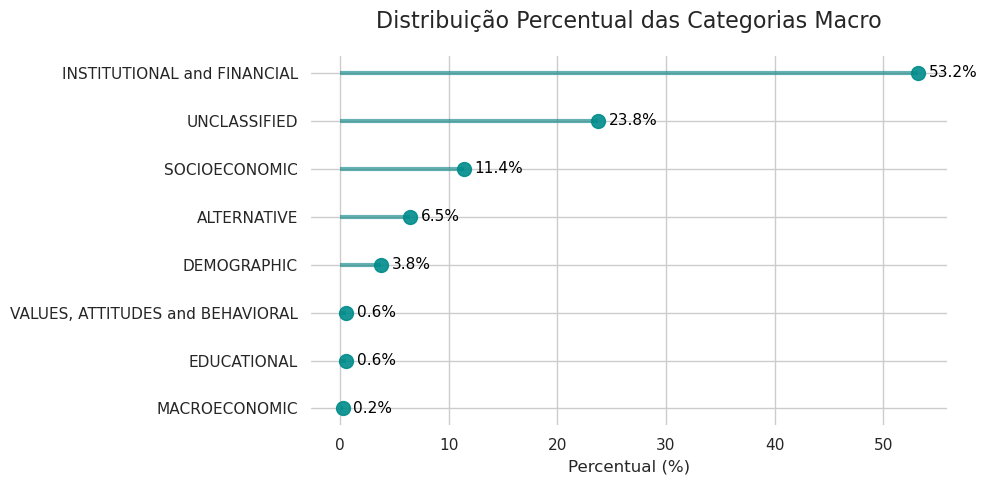

In [10]:
df_MacroTC_percent = df_MacroTC['Col_Standardized'].value_counts(normalize=True) * 100
df_plot = df_MacroTC_percent.reset_index()
df_plot.columns = ['Macro Category', 'Percentage']
df_plot = df_plot.sort_values(by='Percentage', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hlines(y=df_plot['Macro Category'], xmin=0, xmax=df_plot['Percentage'], color='teal', alpha=0.6, linewidth=3)
ax.plot(df_plot['Percentage'], df_plot['Macro Category'], "o", markersize=10, color='darkcyan', alpha=0.9)
for i, v in enumerate(df_plot['Percentage']):
    ax.text(v + 1, i, f'{v:.1f}%', color='black', va='center', fontsize=11)
ax.set_title('Distribuição Percentual das Categorias Macro', fontsize=16, pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12)
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [11]:
df_split_MacroTC_value_counts = df_MacroTC[(df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED')]['Col_Standardized'].value_counts(normalize=True).reset_index().copy()
df_split_MacroTC_value_counts

,Col_Standardized,proportion
0,INSTITUTIONAL and FINANCIAL,0.698389
1,SOCIOECONOMIC,0.149341
2,ALTERNATIVE,0.084919
3,DEMOGRAPHIC,0.049780
4,EDUCATIONAL,0.007321
5,"VALUES, ATTITUDES and BEHAVIORAL",0.007321
6,MACROECONOMIC,0.002928


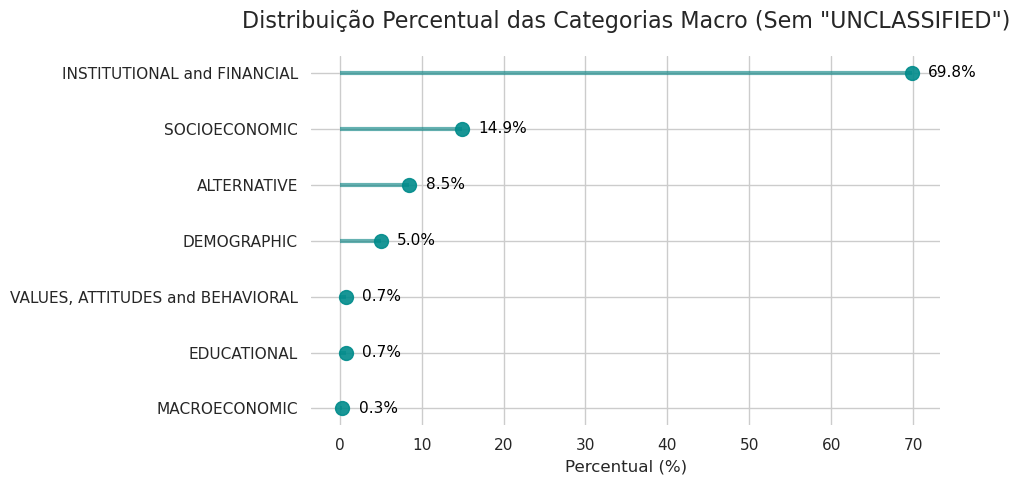

In [12]:
df_plot = df_split_MacroTC_value_counts.copy()
df_plot['Percentage'] = df_plot['proportion'] * 100
df_plot = df_plot.sort_values(by='Percentage', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hlines(y=df_plot['Col_Standardized'], xmin=0, xmax=df_plot['Percentage'], color='teal', alpha=0.6, linewidth=3)
ax.plot(df_plot['Percentage'], df_plot['Col_Standardized'], "o", markersize=10, color='darkcyan', alpha=0.9)
for i, v in enumerate(df_plot['Percentage']):
    ax.text(v + 2, i, f'{v:.1f}%', color='black', va='center', fontsize=11)
ax.set_title('Distribuição Percentual das Categorias Macro (Sem "UNCLASSIFIED")', fontsize=16, pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12)
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---

##### C ) Percentual das Macrocategorias para os Datasets


- <p align="justify">Presença das categorias nos conjuntos de dados analisados. Este gráfico mostra o percentual de bases de dados que possuem pelo menos uma informação referente a cada tema principal. É uma forma direta de observar quais categorias são mais comuns ou mais raras dentro do conjunto total de arquivos coletados para a pesquisa.<p>

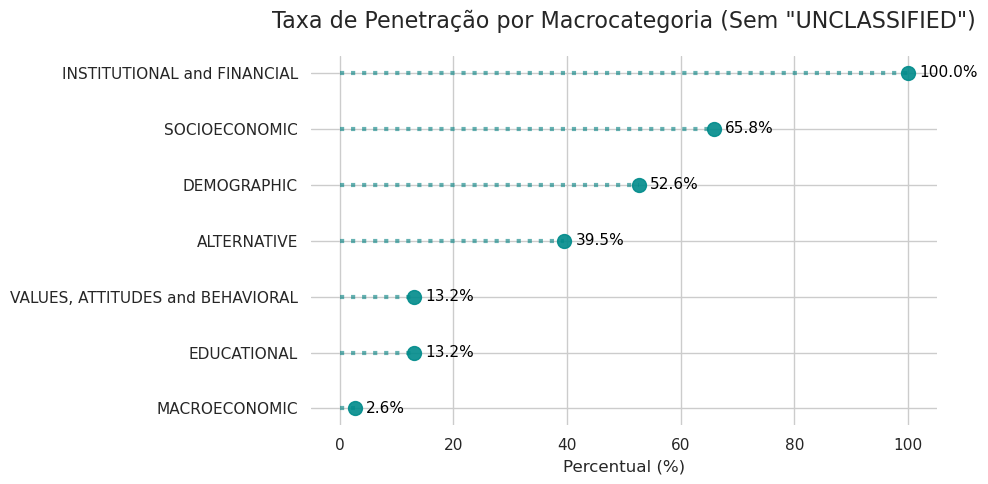

In [13]:
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized']).fillna(0)
df_presenca = (df_crosstab > 0).mean() * 100
df_presenca_plot = df_presenca.reset_index()
df_presenca_plot.columns = ['Macro_Categoria', 'Percentual_Presenca']
df_presenca_plot = df_presenca_plot.sort_values(by='Percentual_Presenca', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hlines(y=df_presenca_plot['Macro_Categoria'], xmin=0, xmax=df_presenca_plot['Percentual_Presenca'], color='teal', alpha=0.6, linewidth=3, linestyles='dotted')
ax.plot(df_presenca_plot['Percentual_Presenca'], df_presenca_plot['Macro_Categoria'], "o", markersize=10, color='darkcyan', alpha=0.9)
for i, v in enumerate(df_presenca_plot['Percentual_Presenca']):
    ax.text(v + 2, i, f'{v:.1f}%', color='black', va='center', fontsize=11)
ax.set_title('Taxa de Penetração por Macrocategoria (Sem "UNCLASSIFIED")', fontsize=16, pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12)
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

---

##### D ) Quantidade média das macro categorias por datasets

- Quantidade média de informações por categoria. Este gráfico mostra, em média, quantas variáveis de cada tema aparecem dentro dos conjuntos de dados estudados. Ele ajuda a entender quais assuntos costumam ser mais detalhados (com várias perguntas ou indicadores) e quais são apresentados de forma mais direta nas bases de crédito.

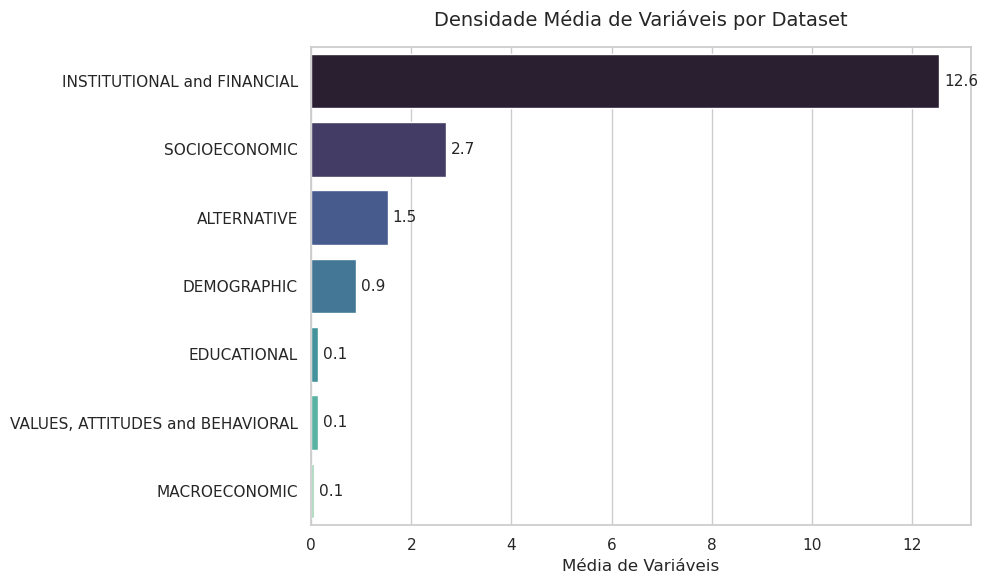

In [14]:
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized']).fillna(0)
df_media = df_crosstab.mean()
df_media_plot = df_media.reset_index()
df_media_plot.columns = ['Macro_Categoria', 'Media_Variaveis']
df_media_plot = df_media_plot.sort_values(by='Media_Variaveis', ascending=False)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Media_Variaveis', y='Macro_Categoria', hue='Macro_Categoria',data=df_media_plot, palette='mako', legend=False,ax=ax)
ax.set_title('Densidade Média de Variáveis por Dataset', fontsize=14, pad=15)
ax.set_xlabel('Média de Variáveis', fontsize=12)
ax.set_ylabel('')
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}', (width + 0.1, p.get_y() + p.get_height() / 2),ha='left', va='center', fontsize=11)
plt.tight_layout()
plt.show()

---

##### E ) Principais Variáveis de Crédito

- <p align="justify">Ranking dos dez termos mais comuns após a limpeza e organização dos dados. Este gráfico destaca quais são as informações que mais se repetem entre todos os conjuntos de dados analisados. É uma forma de visualizar quais são os conceitos fundamentais e mais frequentes que compõem a estrutura dos registros de crédito estudados.</p>

In [15]:
df_MicroTC_value_counts = df_MicroTC['conceito_padronizado'].value_counts().reset_index()
df_MicroTC_value_counts.head(10)

,conceito_padronizado,count
0,monthly_income,26
1,loan_amount,25
2,age,23
3,asset_ownership,20
4,credit_score,14
5,transaction_amount,14
6,loan_purpose,13
7,geographic_region,13
8,credit_rating,12
9,employment_status,12


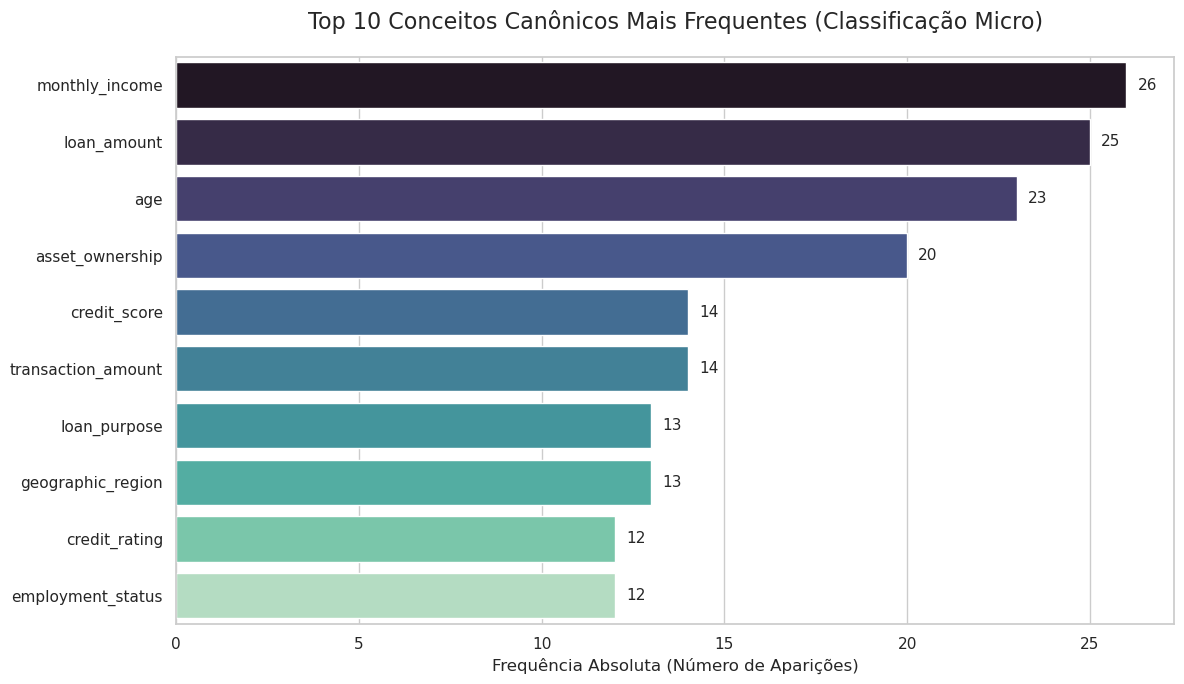

In [16]:
df_MicroTC_value_counts = df_MicroTC['conceito_padronizado'].value_counts().reset_index()
df_MicroTC_value_counts.columns = ['conceito_padronizado', 'count']
df_top10 = df_MicroTC_value_counts.head(10)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='count', y='conceito_padronizado', hue='conceito_padronizado', data=df_top10, palette='mako', legend=False,               ax=ax)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', (width + 0.3, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=11)
ax.set_title('Top 10 Conceitos Canônicos Mais Frequentes (Classificação Micro)', fontsize=16, pad=20)
ax.set_xlabel('Frequência Absoluta (Número de Aparições)', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---

##### E ) Percentual das Microcategorias para os Datasets

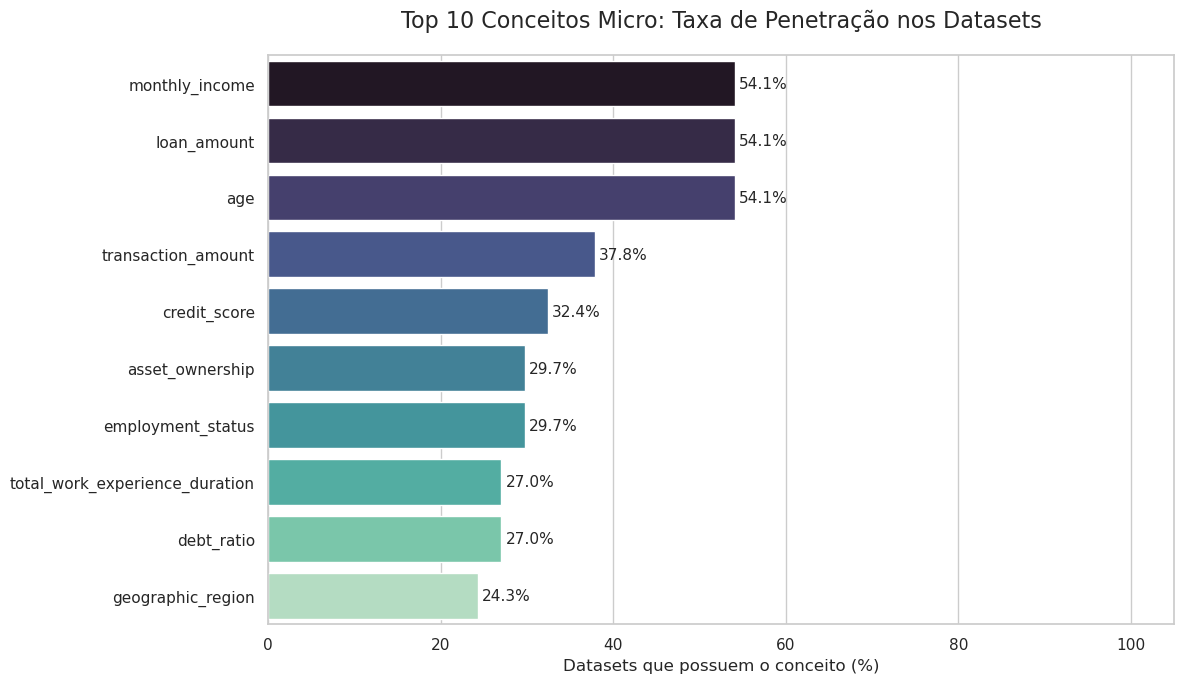

In [17]:
df_Micro_Cross = pd.merge(df_MacroTC[['id', 'Col']], df_MicroTC, left_on='Col', right_on='variavel_original', how='inner')
df_crosstab_micro = pd.crosstab(df_Micro_Cross['id'], df_Micro_Cross['conceito_padronizado']).fillna(0)
df_presenca_micro = (df_crosstab_micro > 0).mean() * 100
df_presenca_micro_plot = df_presenca_micro.reset_index()
df_presenca_micro_plot.columns = ['Conceito_Micro', 'Percentual_Presenca']
df_top10_presenca = df_presenca_micro_plot.sort_values(by='Percentual_Presenca', ascending=False).head(10)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x='Percentual_Presenca', y='Conceito_Micro', hue='Conceito_Micro',data=df_top10_presenca, palette='mako', legend=False,ax=ax)
ax.set_title('Top 10 Conceitos Micro: Taxa de Penetração nos Datasets', fontsize=16, pad=20)
ax.set_xlabel('Datasets que possuem o conceito (%)', fontsize=12)
ax.set_ylabel('')
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', (width + 0.5, p.get_y() + p.get_height() / 2),ha='left', va='center', fontsize=11)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

---

##### F ) ...

In [18]:
df_stats = df_PosDatasetsClean.copy()
df_stats['Numeric_Cols'] = df_stats['Numeric_Cols'].fillna(0)
df_stats['Categorical_Cols'] = df_stats['Categorical_Cols'].fillna(0)
df_stats['Total_Cols'] = df_stats['Numeric_Cols'] + df_stats['Categorical_Cols']
df_stats['Perc_Numeric'] = (df_stats['Numeric_Cols'] / df_stats['Total_Cols']) * 100
df_stats['Perc_Categorical'] = (df_stats['Categorical_Cols'] / df_stats['Total_Cols']) * 100
resumo_estatistico = df_stats[['Perc_Numeric', 'Perc_Categorical']].describe()
print("--- ANÁLISE DESCRITIVA DA MORFOLOGIA ---")
print(resumo_estatistico)
print("-" * 40)

--- ANÁLISE DESCRITIVA DA MORFOLOGIA ---
       Perc_Numeric  Perc_Categorical
count     51.000000         51.000000
mean      66.585813         33.414187
std       27.186458         27.186458
min        0.000000          0.000000
25%       45.625000          9.307359
50%       71.428571         28.571429
75%       90.692641         54.375000
max      100.000000        100.000000
----------------------------------------


---

#### **03 ) - Gráficos Avançados**

---

---

##### A ) Gráfico de Dispersão com Histogramas Marginais

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

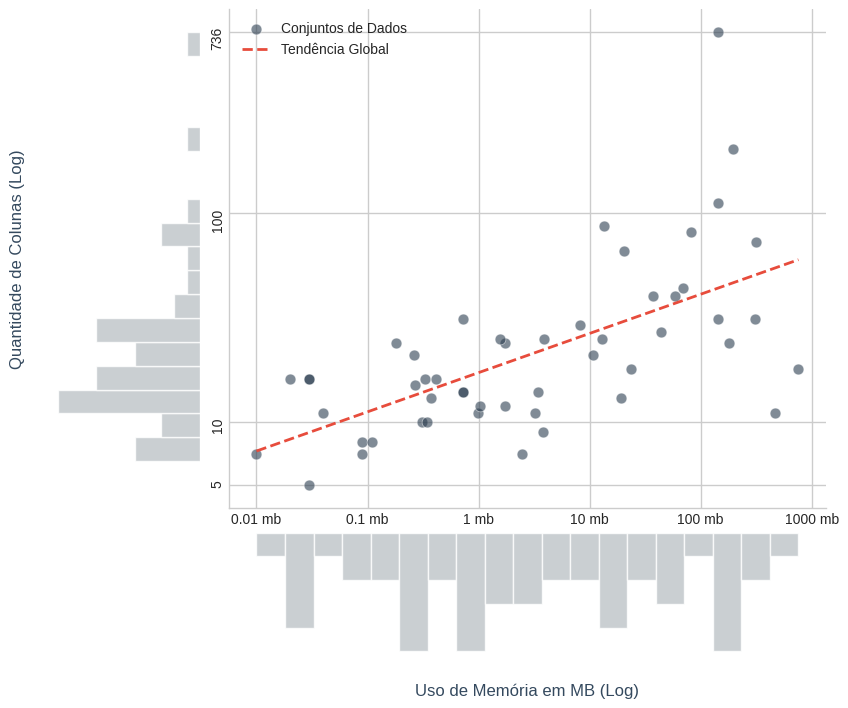

In [20]:
df = df_PosDatasetsClean.copy()
df['Memory_Usage_MB'] = df['Memory_Usage_MB'].astype(str).str.replace(',', '.').astype(float)
df['Columns_Count'] = df['Columns_Count'].astype(float) 
df_clean = df[['Memory_Usage_MB', 'Columns_Count']].dropna()
df_clean = df_clean[(df_clean['Memory_Usage_MB'] > 0) & (df_clean['Columns_Count'] > 0)]
x = df_clean['Memory_Usage_MB']
y = df_clean['Columns_Count']
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(10, 8), facecolor='white')
gs = fig.add_gridspec(2, 2, width_ratios=(1, 4), height_ratios=(4, 1), wspace=0.08, hspace=0.08)
ax_main = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
color_scatter = '#2c3e50' 
color_trend = '#e74c3c'    
color_hist = '#bdc3c7'     
ax_main.scatter(x, y, alpha=0.6, color=color_scatter, edgecolors='white', linewidth=0.5, s=60, label='Conjuntos de Dados')
ax_main.set_xscale('log')
ax_main.set_yscale('log')
log_x = np.log10(x)
log_y = np.log10(y)
z = np.polyfit(log_x, log_y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
ax_main.plot(x_sorted, 10**(p(np.log10(x_sorted))), color=color_trend, linewidth=2, linestyle='--', label='Tendência Global')
bins_x = np.logspace(np.log10(x.min()), np.log10(x.max()), 20)
bins_y = np.logspace(np.log10(y.min()), np.log10(y.max()), 20)
ax_left.hist(y, bins=bins_y, orientation='horizontal', color=color_hist, alpha=0.8)
ax_left.set_yscale('log')
ax_left.invert_xaxis()
ax_bottom.hist(x, bins=bins_x, color=color_hist, alpha=0.8)
ax_bottom.set_xscale('log')
ax_bottom.invert_yaxis()
min_y = y.min()
max_y = y.max()
min_power = int(np.ceil(np.log10(min_y)))
max_power = int(np.floor(np.log10(max_y)))
intermediarios = [10**i for i in range(min_power, max_power + 1)]
valores_desejados = [min_y] + intermediarios + [max_y]
novos_yticks = sorted(list(set(valores_desejados)))
ax_main.set_yticks(novos_yticks)
formatter_x = FuncFormatter(lambda val, pos: f"{val:g} mb")
formatter_y = FuncFormatter(lambda val, pos: f"{val:g}")
ax_main.xaxis.set_major_formatter(formatter_x)
ax_main.yaxis.set_major_formatter(formatter_y)
for ax in [ax_main, ax_left, ax_bottom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
ax_left.spines['left'].set_visible(False)
ax_left.spines['bottom'].set_visible(False)
ax_bottom.spines['bottom'].set_visible(False)
ax_bottom.spines['left'].set_visible(False)
ax_left.grid(False)
ax_bottom.grid(False)
ax_left.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_bottom.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_main.tick_params(axis="y", left=True, labelleft=True, labelsize=10, labelrotation=90)
ax_main.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10)
ax_left.set_ylabel('Quantidade de Colunas (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_bottom.set_xlabel('Uso de Memória em MB (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_main.legend(loc='upper left', frameon=False, fontsize=10)
fig.subplots_adjust(top=0.92) 
plt.show()

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

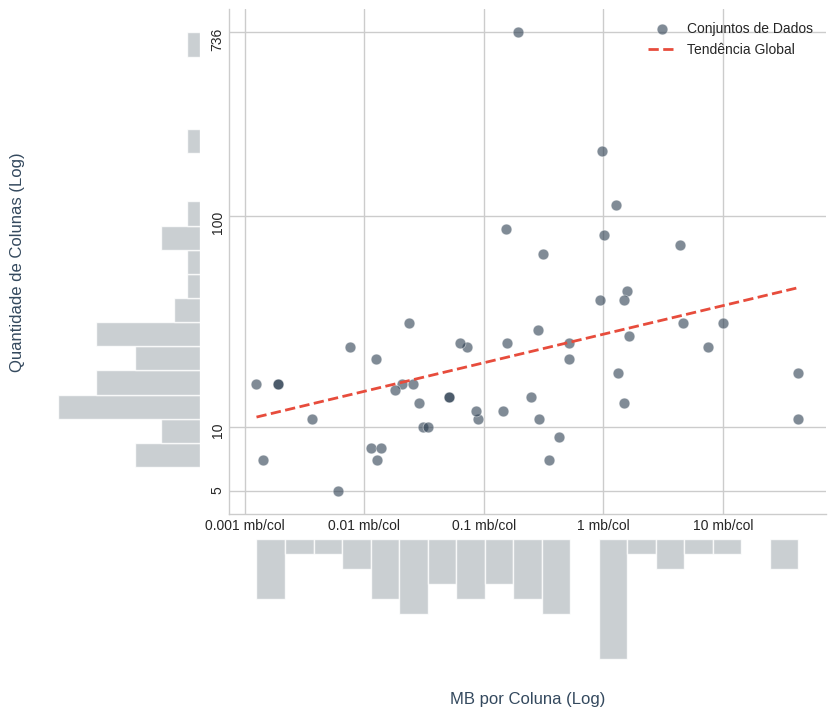

In [22]:
df = df_PosDatasetsClean.copy()
df['Memory_Usage_MB'] = df['Memory_Usage_MB'].astype(str).str.replace(',', '.').astype(float)
df['Columns_Count'] = df['Columns_Count'].astype(float) 
df_clean = df[['Memory_Usage_MB', 'Columns_Count']].dropna()
df_clean = df_clean[(df_clean['Memory_Usage_MB'] > 0) & (df_clean['Columns_Count'] > 0)]
x = df_clean['Memory_Usage_MB'] / df_clean['Columns_Count']
y = df_clean['Columns_Count']
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(10, 8), facecolor='white')
gs = fig.add_gridspec(2, 2, width_ratios=(1, 4), height_ratios=(4, 1), wspace=0.08, hspace=0.08)
ax_main = fig.add_subplot(gs[0, 1])
ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
ax_bottom = fig.add_subplot(gs[1, 1], sharex=ax_main)
color_scatter = '#2c3e50' 
color_trend = '#e74c3c'    
color_hist = '#bdc3c7'     
ax_main.scatter(x, y, alpha=0.6, color=color_scatter, edgecolors='white', linewidth=0.5, s=60, label='Conjuntos de Dados')
ax_main.set_xscale('log')
ax_main.set_yscale('log')
log_x = np.log10(x)
log_y = np.log10(y)
z = np.polyfit(log_x, log_y, 1)
p = np.poly1d(z)
x_sorted = np.sort(x)
ax_main.plot(x_sorted, 10**(p(np.log10(x_sorted))), color=color_trend, linewidth=2, linestyle='--', label='Tendência Global')
bins_x = np.logspace(np.log10(x.min()), np.log10(x.max()), 20)
bins_y = np.logspace(np.log10(y.min()), np.log10(y.max()), 20)
ax_left.hist(y, bins=bins_y, orientation='horizontal', color=color_hist, alpha=0.8)
ax_left.set_yscale('log')
ax_left.invert_xaxis()
ax_bottom.hist(x, bins=bins_x, color=color_hist, alpha=0.8)
ax_bottom.set_xscale('log')
ax_bottom.invert_yaxis()
min_y = y.min()
max_y = y.max()
min_power = int(np.ceil(np.log10(min_y)))
max_power = int(np.floor(np.log10(max_y)))
intermediarios = [10.0**i for i in range(min_power, max_power + 1)]
valores_desejados = [min_y] + intermediarios + [max_y]
novos_yticks = sorted(list(set(valores_desejados)))
ax_main.set_yticks(novos_yticks)
formatter_x = FuncFormatter(lambda val, pos: f"{val:g} mb/col")
formatter_y = FuncFormatter(lambda val, pos: f"{val:g}")
ax_main.xaxis.set_major_formatter(formatter_x)
ax_main.yaxis.set_major_formatter(formatter_y)
for ax in [ax_main, ax_left, ax_bottom]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
ax_left.spines['left'].set_visible(False)
ax_left.spines['bottom'].set_visible(False)
ax_bottom.spines['bottom'].set_visible(False)
ax_bottom.spines['left'].set_visible(False)
ax_left.grid(False)
ax_bottom.grid(False)
ax_left.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_bottom.tick_params(axis="both", left=False, labelleft=False, bottom=False, labelbottom=False) 
ax_main.tick_params(axis="y", left=True, labelleft=True, labelsize=10, labelrotation=90)
ax_main.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10)
ax_left.set_ylabel('Quantidade de Colunas (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_bottom.set_xlabel('MB por Coluna (Log)', fontsize=12, color='#34495e', labelpad=15)
ax_main.legend(loc='upper right', frameon=False, fontsize=10)
fig.subplots_adjust(top=0.92, bottom=0.1) 
plt.show()

---

##### B ) Word Cloud Filtrado por Macro

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import matplotlib.colors as mcolors
import numpy as np

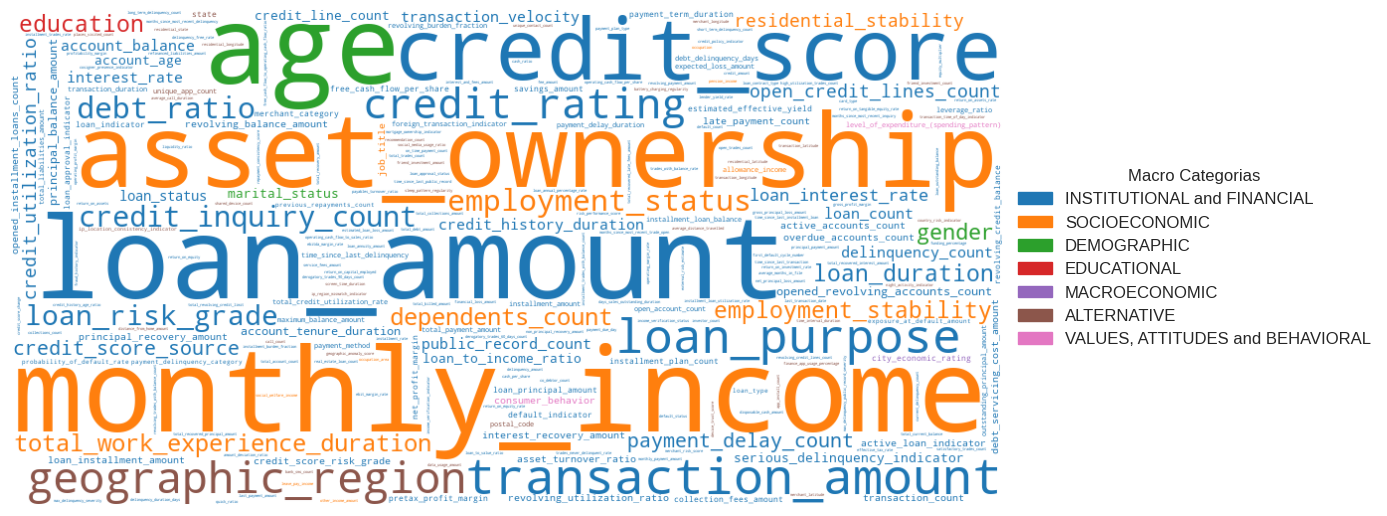

In [24]:
df = df_MicroTC.copy()
df = df.dropna(subset=['conceito_padronizado', 'macro_categoria'])
word_freq = df['conceito_padronizado'].value_counts().to_dict()
word_to_category = df.groupby('conceito_padronizado')['macro_categoria'].first().to_dict()
categories = df['macro_categoria'].unique()
cmap = plt.get_cmap('tab10')
category_colors = {cat: mcolors.to_hex(cmap(i % 10)) for i, cat in enumerate(categories)}
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    cat = word_to_category.get(word, categories[0])
    return category_colors.get(cat, "#000000")
wc = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    color_func=color_func,
    prefer_horizontal=0.9, 
    max_words=250,         
    random_state=42       
)
wc.generate_from_frequencies(word_freq)
plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off") # Esconde os eixos (números)
handles = [plt.Rectangle((0,0), 1, 1, color=category_colors[cat]) for cat in categories]
plt.legend(handles, 
           categories, 
           loc='center left', 
           bbox_to_anchor=(1, 0.5), 
           title="Macro Categorias", 
           fontsize='medium')
plt.tight_layout()
plt.show()

---

##### C ) .

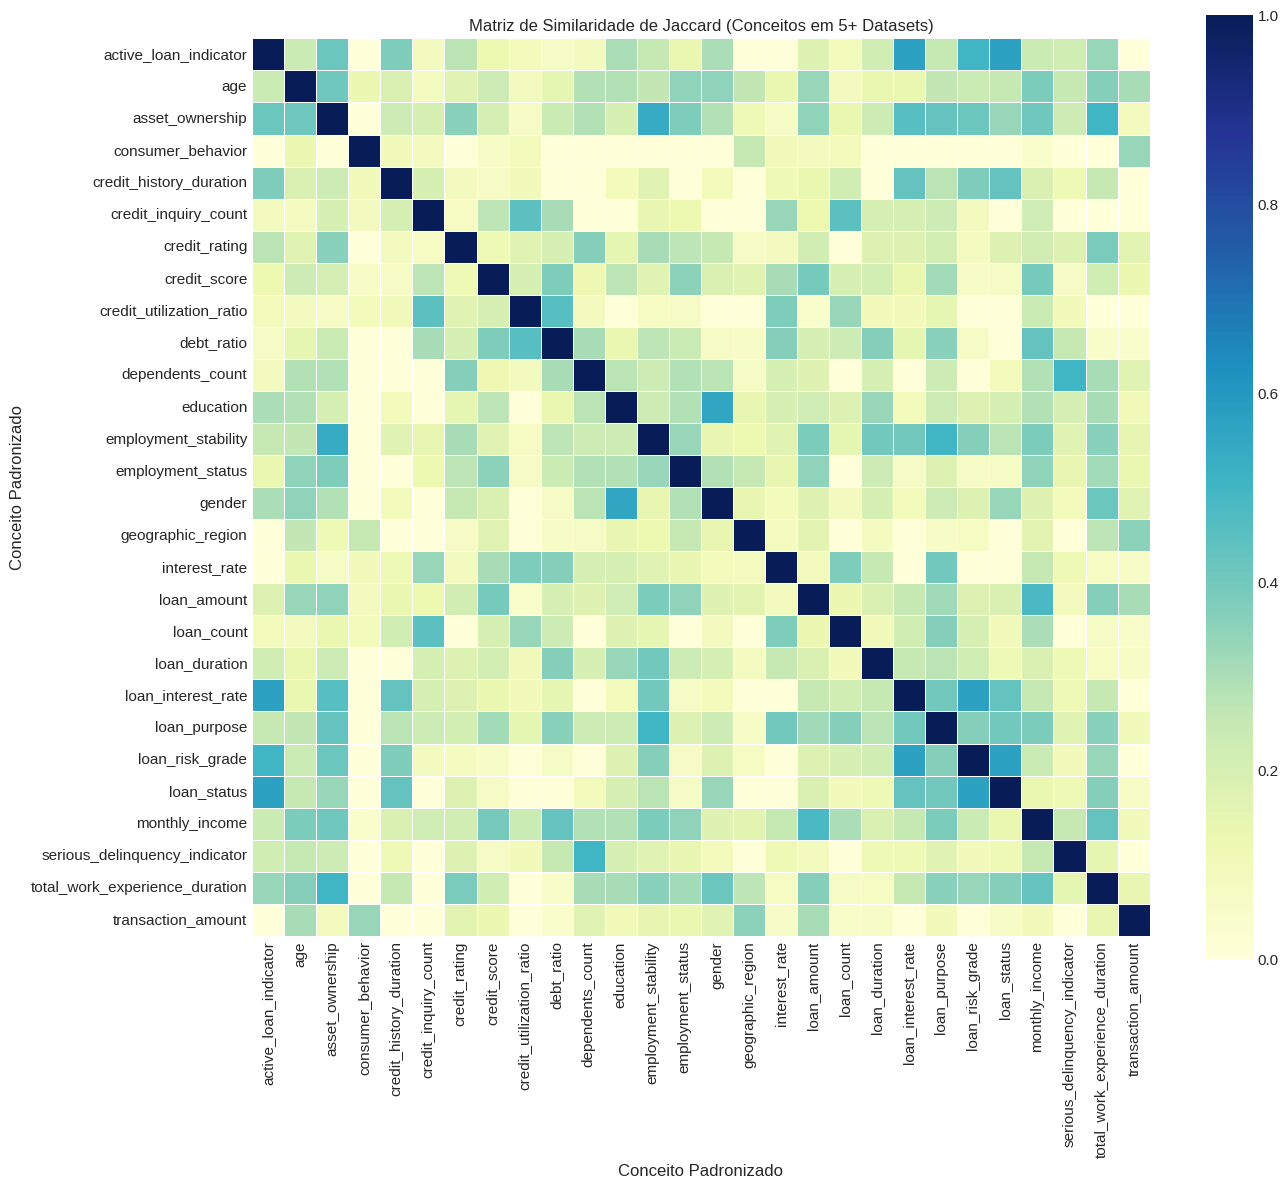

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregando os DataFrames

# 2. Fazendo o cruzamento (map)
df_merged = df_MacroTC.merge(df_MicroTC, left_on='Col', right_on='variavel_original', how='inner')

# 3. Removendo duplicatas
df_unique = df_merged[['id', 'conceito_padronizado']].drop_duplicates()

# 4. Filtro de Relevância e Esparsidade
# Exige que o conceito apareça em pelo menos 5 'ids' diferentes
contagem = df_unique['conceito_padronizado'].value_counts()
conceitos_validos = contagem[contagem >= 5].index
df_filtrado = df_unique[df_unique['conceito_padronizado'].isin(conceitos_validos)]

# 5. Criando a matriz binária de presença
pivot_df = df_filtrado.assign(val=1).pivot(index='id', columns='conceito_padronizado', values='val').fillna(0)

# 6. Cálculo Matemático
# Matriz de co-ocorrência pura (produto escalar)
co_occ = pivot_df.T.dot(pivot_df)

# Similaridade de Jaccard: J(A,B) = Co-occ / (Total A + Total B - Co-occ)
contagens_diagonais = np.diag(co_occ)
uniao = contagens_diagonais[:, None] + contagens_diagonais[None, :] - co_occ
matriz_jaccard = co_occ / uniao

# 7. Plotando o Gráfico (Heatmap)
plt.figure(figsize=(14, 12))
sns.heatmap(
    matriz_jaccard, 
    cmap='YlGnBu', # Paleta Amarelo (0) para Azul Escuro (1)
    center=0.5, 
    annot=False,     
    square=True, 
    linewidths=.5
)

plt.title("Matriz de Similaridade de Jaccard (Conceitos em 5+ Datasets)")
plt.xlabel("Conceito Padronizado")
plt.ylabel("Conceito Padronizado")
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd

# 1. Carregando os dados
df_micro = df_MicroTC.copy()
# Correção aplicada na linha abaixo: referenciando o dataframe antes da coluna
df_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()

# 2. Total de variáveis analisadas no dataset Macro
total_macro = len(df_macro)

# 3. Resultado do cruzamento (Inner Join)
df_merged = df_macro.merge(df_micro, left_on='Col', right_on='variavel_original', how='inner')
total_matched = len(df_merged)

# 4. Descobrindo o que ficou de fora (Filtro reverso)
mascara_perdidos = ~df_macro['Col'].isin(df_micro['variavel_original'])
df_missing = df_macro[mascara_perdidos]
total_missing = len(df_missing)

# 5. Calculando a porcentagem de perda
percent_missing = (total_missing / total_macro) * 100

# 6. Identificando as variáveis perdidas mais comuns
top_missing_vars = df_missing['Col'].value_counts().head(10)

print(f"Total de linhas no dataset Macro: {total_macro}")
print(f"Linhas resultantes após o cruzamento: {total_matched}")
print(f"Variáveis descartadas (sem correspondência): {total_missing} ({percent_missing:.2f}%)")
print("\nTop 10 variáveis descartadas:")
print(top_missing_vars)

Total de linhas no dataset Macro: 683
Linhas resultantes após o cruzamento: 942
Variáveis descartadas (sem correspondência): 16 (2.34%)

Top 10 variáveis descartadas:
Col
no_of_dependents            1
education                   1
self_employed               1
income_annum                1
loan_amount                 1
loan_term                   1
cibil_score                 1
residential_assets_value    1
commercial_assets_value     1
luxury_assets_value         1
Name: count, dtype: int64


---

#### D ) . 

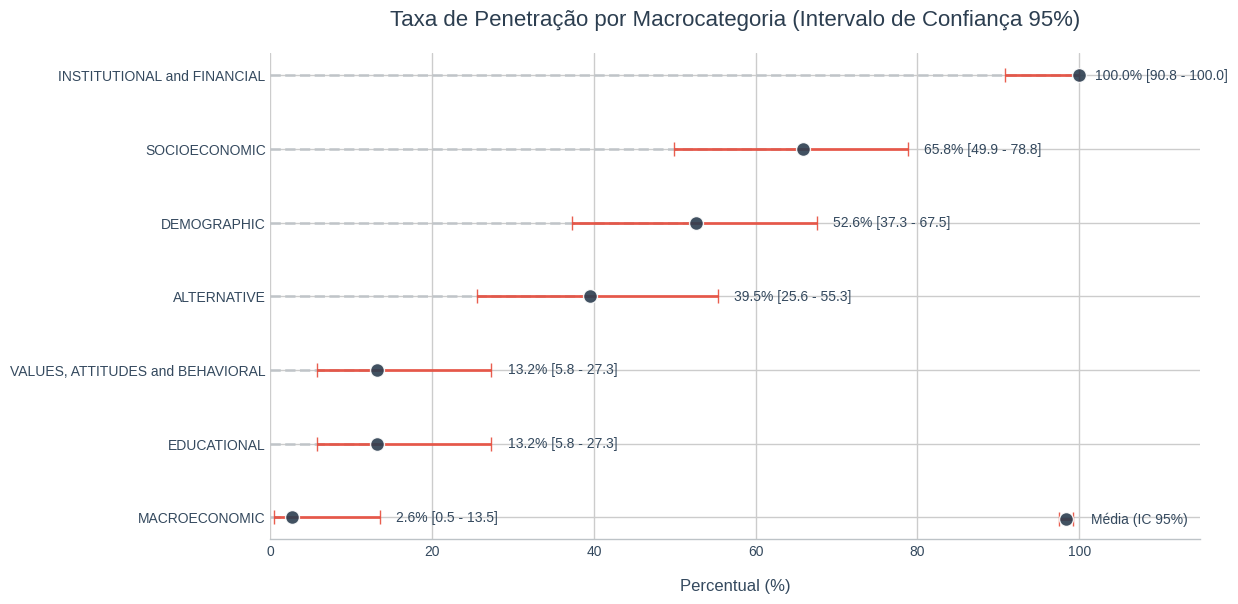

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportion_confint
df_valid_macro = df_MacroTC[df_MacroTC['Col_Standardized'] != 'UNCLASSIFIED'].copy()
df_crosstab = pd.crosstab(df_valid_macro['id'], df_valid_macro['Col_Standardized']).fillna(0)
df_presenca_bin = (df_crosstab > 0).astype(int)
n_amostras = len(df_presenca_bin)
sucessos = df_presenca_bin.sum()
media_presenca = (sucessos / n_amostras) * 100
ci_lower, ci_upper = proportion_confint(sucessos, n_amostras, alpha=0.05, method='wilson')
ci_lower = ci_lower * 100
ci_upper = ci_upper * 100
df_estatisticas = pd.DataFrame({
    'Macro_Categoria': media_presenca.index,
    'Media_Presenca': media_presenca.values,
    'CI_Lower': ci_lower,
    'CI_Upper': ci_upper
})
df_estatisticas = df_estatisticas.sort_values(by='Media_Presenca', ascending=True).reset_index(drop=True)
erro_inferior = df_estatisticas['Media_Presenca'] - df_estatisticas['CI_Lower']
erro_superior = df_estatisticas['CI_Upper'] - df_estatisticas['Media_Presenca']
erros_assimetricos = [erro_inferior, erro_superior]
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
color_scatter = '#2c3e50' 
color_error = '#e74c3c'    
color_line = '#bdc3c7'
ax.hlines(y=df_estatisticas['Macro_Categoria'], xmin=0, xmax=df_estatisticas['Media_Presenca'], 
          color=color_line, alpha=0.8, linewidth=2, linestyles='--')
ax.errorbar(df_estatisticas['Media_Presenca'], df_estatisticas['Macro_Categoria'], 
            xerr=erros_assimetricos, 
            fmt='o', color=color_scatter, ecolor=color_error, alpha=0.9, markersize=10, 
            capsize=5, capthick=2, elinewidth=2, label='Média (IC 95%)',
            markeredgecolor='white', markeredgewidth=1)
for i, row in df_estatisticas.iterrows():
    texto = f"{row['Media_Presenca']:.1f}% [{row['CI_Lower']:.1f} - {row['CI_Upper']:.1f}]"
    offset = row['CI_Upper'] + 2
    ax.text(offset, i, texto, color='#34495e', va='center', fontsize=10)
ax.set_title('Taxa de Penetração por Macrocategoria (Intervalo de Confiança 95%)', fontsize=16, color='#2c3e50', pad=20)
ax.set_xlabel('Percentual (%)', fontsize=12, color='#34495e', labelpad=15)
ax.set_ylabel('')
ax.set_xlim(0, 115) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#bdc3c7')
ax.tick_params(axis="y", left=False, labelleft=True, labelsize=10, labelcolor='#34495e')
ax.tick_params(axis="x", bottom=True, labelbottom=True, labelsize=10, labelcolor='#34495e')
ax.legend(loc='lower right', frameon=False, fontsize=10, labelcolor='#34495e')
fig.subplots_adjust(top=0.92) 
plt.show()